**RF-SVR model**

In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from itertools import product
import tensorflow as tf
import shap
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
df = pd.read_csv('../data/df_with_2regimes.csv')

# take log of realized variance
df['log_realized_variance'] = np.log(df['realized_variance'])
# lag 1,2 andd 3 of log realized variance
df['rv_lag1'] = df['log_realized_variance'].shift(1)
df['rv_lag2'] = df['log_realized_variance'].shift(2)
df['rv_lag3'] = df['log_realized_variance'].shift(3)

# rolling mean of log realized variance over the past 30 days
df['rv_rolling_mean_30'] = df['log_realized_variance'].rolling(window=30).mean() 

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
df.head(30)
df.info()
# start from 2017-07-13
df = df[df['date'] >= '2017-07-13'].reset_index(drop=True)
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489 entries, 0 to 3488
Data columns (total 42 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        3489 non-null   object 
 1   log_return                                  3489 non-null   float64
 2   realized_variance                           3489 non-null   float64
 3   realized_volatility                         3489 non-null   float64
 4   gtrend_pct_change                           3489 non-null   float64
 5   blockchain_diff_log_n_transactions          3489 non-null   float64
 6   blockchain_diff_log_transaction_fee_usd     3489 non-null   float64
 7   blockchain_diff_log_n_unique_addresses      3489 non-null   float64
 8   blockchain_diff_log_transaction_volume_usd  3489 non-null   float64
 9   log_volume                                  3489 non-null   float64
 10  target      

In [3]:
rf_features = ["log_return", "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg"
    ]

svr_features = ["rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]
svr_features.extend(rf_features)

target_col = "regime_id"

In [4]:
n = len(df)

train_size = int(n * 0.60)  # 60/25/15 split
eval_size  = int(n * 0.25)

train_start_idx = 0
train_end_idx   = train_size

eval_start_idx = train_end_idx
eval_end_idx   = eval_start_idx + eval_size

test_start_idx = eval_end_idx
test_end_idx   = n

# split eval into A and B
evalA_size = eval_size // 2

evalA_start_idx = eval_start_idx
evalA_end_idx   = evalA_start_idx + evalA_size

evalB_start_idx = evalA_end_idx
evalB_end_idx   = eval_end_idx

train_df = df.iloc[train_start_idx:train_end_idx].copy()
evalA_df = df.iloc[evalA_start_idx:evalA_end_idx].copy()
evalB_df = df.iloc[evalB_start_idx:evalB_end_idx].copy()
test_df  = df.iloc[test_start_idx:test_end_idx].copy()

print(f"Train set:  {len(train_df)} rows")
print(f"Eval A set: {len(evalA_df)} rows")
print(f"Eval B set: {len(evalB_df)} rows")
print(f"Test set:   {len(test_df)} rows")

Train set:  1875 rows
Eval A set: 390 rows
Eval B set: 391 rows
Test set:   469 rows


# Stage 1 RF Regime Prediction

In [5]:
def train_random_forest(
    X_train,
    y_train,
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    random_state=SEED
):
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=-1
    )
    
    rf_model.fit(X_train, y_train)
    return rf_model

In [6]:
def rolling_regime_forecast_rf(
    df_full,
    rf_model,
    feature_cols,
    start_idx,
    end_idx,
    date_col="date"
):
    results = []

    for t in range(start_idx - 1, end_idx - 1):
        current_row = df_full.iloc[t]

        x_t = current_row[feature_cols]

        if x_t.isna().any():
            continue

        X_input = x_t.values.reshape(1, -1)

        pred_regime = rf_model.predict(X_input)[0]
        pred_probs = rf_model.predict_proba(X_input)[0]

        results.append({
            "date": current_row[date_col],
            "pred_regime": int(pred_regime),
            "pred_prob_0": pred_probs[0],
            "pred_prob_1": pred_probs[1] if len(pred_probs) > 1 else 0.0
        })

    return pd.DataFrame(results)

In [7]:
def rolling_regime_forecast_rf(
    df_full,
    rf_model,
    feature_cols,
    start_idx,
    end_idx,
    date_col="date"
):
    results = []

    for t in range(start_idx - 1, end_idx - 1):
        current_row = df_full.iloc[t]

        x_t = current_row[feature_cols]

        if x_t.isna().any():
            continue

        X_input = x_t.values.reshape(1, -1)

        pred_probs = rf_model.predict_proba(X_input)
        pred_regime = int(np.argmax(pred_probs[0]))

        results.append({
            "date": current_row[date_col],
            "pred_regime": pred_regime,
            "pred_prob_0": pred_probs[0, 0],
            "pred_prob_1": pred_probs[0, 1]
        })

    return pd.DataFrame(results)

# Stage 2 SVR-Linear

In [8]:
def one_step_svr_forecast(fitted_svr, x_next):
    
    if fitted_svr is None:
        return np.nan

    try:
        x_next = np.asarray(x_next).reshape(1, -1)
        pred = fitted_svr.predict(x_next)[0]
        return float(pred)
    except Exception:
        return np.nan

    
def fit_svr_safe(X_train, y_train, C=1.0, epsilon=1e-4, min_obs=100):
    if len(X_train) < min_obs:
        return None

    try:
        model = LinearSVR(C=C, epsilon=epsilon, dual=True, max_iter=20000, random_state=SEED)
        model.fit(X_train, y_train)
        return model
    except Exception as e:
        print("LinearSVR fit failed:", e)
        return None

In [9]:
def rolling_rf_svr_linear_eval(
    df_full,
    regime_forecast_df,
    start_idx,
    end_idx,
    x_feature_cols,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=1.0,
    epsilon=1e-4,
    min_obs=200,
    use_prob_1_only=True
):
    results = []

    df = df_full.copy()
    regime_df = regime_forecast_df.copy()

    merge_cols = [date_col, "pred_regime", "pred_prob_0", "pred_prob_1"]
    df = df.merge(regime_df[merge_cols], on=date_col, how="left")

    # target is next day's realized variance
    df["rv_lead1"] = df[realized_var_col].shift(-1)

    # row t stores regime forecast for t+1 made using info up to t
    df["prob1_for_next_day"] = df["pred_prob_1"]
    df["prob0_for_next_day"] = df["pred_prob_0"]
    df["regime_for_next_day"] = df["pred_regime"]

    prob_cols = ["prob1_for_next_day"] if use_prob_1_only else ["prob0_for_next_day", "prob1_for_next_day"]
    feature_cols = x_feature_cols + prob_cols

    for t in range(start_idx - 1, end_idx - 1):
        current_row = df.iloc[t]
        next_row = df.iloc[t + 1]

        current_date = current_row[date_col]
        next_date = next_row[date_col]

        # training ends at t-1, so row t is excluded
        window_df = df.iloc[max(0, t - rolling_window + 1): t].copy()

        needed_cols = feature_cols + ["rv_lead1"]
        train_df = window_df[needed_cols].dropna()

        if len(train_df) < min_obs:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_var": next_row[realized_var_col],
                "pred_regime": current_row.get("regime_for_next_day", np.nan),
                "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
                "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
                "var_svr": np.nan
            })
            continue
 
        # split continuous features and probability features to scale separately
        X_train_cont = train_df[x_feature_cols].values
        X_train_prob = train_df[prob_cols].values
        y_train = train_df["rv_lead1"].values

        # scale only continuous features
        scaler = StandardScaler()
        X_train_cont_scaled = scaler.fit_transform(X_train_cont)

        # combine scaled continuous features with raw probabilities
        X_train_final = np.hstack([X_train_cont_scaled, X_train_prob])

        model = fit_svr_safe(
            X_train=X_train_final,
            y_train=y_train,
            C=C,
            epsilon=epsilon,
            min_obs=min_obs
        )

        # prepare current row features for forecasting t+1
        x_t_cont = current_row[x_feature_cols]
        x_t_prob = current_row[prob_cols]

        if x_t_cont.isna().any() or x_t_prob.isna().any():
            pred = np.nan
        else:
            x_t_cont_scaled = scaler.transform(x_t_cont.values.reshape(1, -1))
            x_t_prob_arr = x_t_prob.values.reshape(1, -1)
            x_t_final = np.hstack([x_t_cont_scaled, x_t_prob_arr])

            pred = one_step_svr_forecast(model, x_t_final)

        results.append({
            "date": next_date,
            "forecast_origin_date": current_date,
            "actual_log_var": next_row[realized_var_col],
            "pred_regime": current_row.get("regime_for_next_day", np.nan),
            "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
            "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
            "log_var_svr": pred
        })

    return pd.DataFrame(results)

#### metrics


In [10]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))

def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)
    
    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)
    
    return test_qlike

In [11]:
# Define parameter grids
rf_grid = {
    "n_estimators": [500, 1000],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

rf_param_grid = []
for n_est, max_depth, min_leaf in product(
    rf_grid["n_estimators"],
    rf_grid["max_depth"],
    rf_grid["min_samples_leaf"]
):
    rf_param_grid.append({
        "n_estimators": n_est,
        "max_depth": max_depth,
        "min_samples_leaf": min_leaf
    })


# SVR grid (same as before)
svr_grid = {
    "kernel": ["linear"],
    "C": [0.1, 1.0, 10.0],
    "epsilon": [1e-4, 1e-3, 1e-2]
}

svr_param_grid = []
for kernel, C, epsilon in product(
    svr_grid["kernel"],
    svr_grid["C"],
    svr_grid["epsilon"]
):
    svr_param_grid.append({
        "kernel": kernel,
        "C": C,
        "epsilon": epsilon
    })

print(f"Total RF configs: {len(rf_param_grid)}")
print(f"Total SVR configs: {len(svr_param_grid)}")

Total RF configs: 18
Total SVR configs: 9


In [12]:
fixed_svr_params = {
    "kernel": "linear",
    "C": 1.0,
    "epsilon": 1e-4
}

stage2_window = 365
min_obs = 200

rf_results = []

for i, params in enumerate(rf_param_grid, 1):
    n_est = params["n_estimators"]
    max_depth = params["max_depth"]
    min_samples_leaf = params["min_samples_leaf"]

    print(f"\n[{i}/{len(rf_param_grid)}] Testing RF: {params}")

    try:
        # -----------------------------
        # 1) Train RF on TRAIN only
        # -----------------------------
        train_rf_df = train_df[rf_features + [target_col]].dropna()

        if len(train_rf_df) == 0:
            print("Skipping: no valid RF training rows.")
            rf_results.append({
                **params,
                "evalB_rmse": np.nan,
                "evalB_qlike": np.nan,
                "n_evalB_forecasts": 0,
                "error": "no valid RF training rows"
            })
            continue

        X_train_rf = train_rf_df[rf_features].values
        y_train_rf = train_rf_df[target_col].values

        rf_model = train_random_forest(
            X_train=X_train_rf,
            y_train=y_train_rf,
            n_estimators=n_est,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=SEED
        )

        # ---------------------------------------------------------
        # 2) Generate regime probabilities on Eval A + Eval B
        #    starting early enough for stage-2 rolling history
        # ---------------------------------------------------------
        regime_start_idx = max(0, evalA_start_idx - stage2_window)

        evalAB_regime_roll = rolling_regime_forecast_rf(
            df_full=df,
            rf_model=rf_model,
            feature_cols=rf_features,
            start_idx=regime_start_idx,
            end_idx=evalB_end_idx,
            date_col="date"
        )

        if len(evalAB_regime_roll) == 0:
            print("Skipping: no RF regime forecasts produced.")
            rf_results.append({
                **params,
                "evalB_rmse": np.nan,
                "evalB_qlike": np.nan,
                "n_evalB_forecasts": 0,
                "error": "no RF regime forecasts produced"
            })
            continue

        # ------------------------------------------------
        # 3) Tune/evaluate stage-2 SVR on Eval B only
        # ------------------------------------------------
        evalB_stage2 = rolling_rf_svr_linear_eval(
            df_full=df,
            regime_forecast_df=evalAB_regime_roll,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=stage2_window,
            C=fixed_svr_params["C"],
            epsilon=fixed_svr_params["epsilon"],
            min_obs=min_obs,
            use_prob_1_only=True
        )

        valid_evalB = evalB_stage2.dropna(subset=["actual_log_var", "log_var_svr"]).copy()

        if len(valid_evalB) == 0:
            print("Skipping: no valid stage-2 forecasts.")
            rf_results.append({
                **params,
                "evalB_rmse": np.nan,
                "evalB_qlike": np.nan,
                "n_evalB_forecasts": 0,
                "error": "no valid stage-2 forecasts"
            })
            continue

        evalB_rmse = rmse(valid_evalB["actual_log_var"], valid_evalB["log_var_svr"])
        # convert to variance scale for qlike
        evalB_qlike = qlike(
            np.exp(valid_evalB["actual_log_var"]),
            np.exp(valid_evalB["log_var_svr"])
        )
        n_evalB_forecasts = valid_evalB["log_var_svr"].notna().sum()

        rf_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })

    except Exception as e:
        print(f"Error for params {params}: {e}")
        rf_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

rf_results_df = pd.DataFrame(rf_results).sort_values("evalB_qlike")
print(rf_results_df.head())


[1/18] Testing RF: {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1}

[2/18] Testing RF: {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 5}

[3/18] Testing RF: {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 10}

[4/18] Testing RF: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1}

[5/18] Testing RF: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 5}

[6/18] Testing RF: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 10}

[7/18] Testing RF: {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 1}

[8/18] Testing RF: {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 5}

[9/18] Testing RF: {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 10}

[10/18] Testing RF: {'n_estimators': 1000, 'max_depth': None, 'min_samples_leaf': 1}

[11/18] Testing RF: {'n_estimators': 1000, 'max_depth': None, 'min_samples_leaf': 5}

[12/18] Testing RF: {'n_estimators': 1000, 'max_depth': None, 'min_samples_leaf': 1

In [13]:
best_rf_params = rf_results_df.iloc[0].to_dict()
print(best_rf_params)

{'n_estimators': 500.0, 'max_depth': 5.0, 'min_samples_leaf': 1.0, 'evalB_rmse': 1.0307069220649767, 'evalB_qlike': 0.6348736992740414, 'n_evalB_forecasts': 391.0}


In [14]:
best_estimators = int(best_rf_params["n_estimators"])
best_max_depth = None if pd.isna(best_rf_params["max_depth"]) else int(best_rf_params["max_depth"])
best_min_samples_leaf = int(best_rf_params["min_samples_leaf"])

best_estimators, best_max_depth, best_min_samples_leaf

(500, 5, 1)

In [18]:
# hardcode here so don't need to rerun training everytime (updated for rf-svr_update2)
#best_estimators = 5000
#best_max_depth = 5
#best_min_samples_leaf = 1
#best_rf_params = {
#    "n_estimators": 500,
#    "max_depth": 10,
#    "min_samples_leaf": 5
#}

#best_estimators, best_max_depth, best_min_samples_leaf

In [15]:
stage2_window = 365

# -----------------------------
# 1) Train best RF on TRAIN
# -----------------------------
train_rf_df = train_df[rf_features + [target_col]].dropna()

if len(train_rf_df) == 0:
    raise ValueError("No valid RF training rows.")

X_train_rf = train_rf_df[rf_features].values
y_train_rf = train_rf_df[target_col].values

rf_model = train_random_forest(
    X_train=X_train_rf,
    y_train=y_train_rf,
    n_estimators=best_estimators,
    max_depth=best_max_depth,
    min_samples_leaf=best_min_samples_leaf,
    random_state=SEED
)

# -----------------------------
# 2) Generate fixed regime probabilities
#    for stage-2 SVR tuning on Eval B
# -----------------------------
# start early enough so stage-2 has rolling history
regime_start_idx = max(0, evalB_start_idx - stage2_window)

eval_regime_fixed = rolling_regime_forecast_rf(
    df_full=df,
    rf_model=rf_model,
    feature_cols=rf_features,
    start_idx=regime_start_idx,
    end_idx=evalB_end_idx,
    date_col="date"
)

if len(eval_regime_fixed) == 0:
    raise ValueError("No RF regime forecasts produced.")

# -----------------------------
# 3) Tune stage-2 SVR on Eval B
# -----------------------------
svr_results = []

for i, params in enumerate(svr_param_grid, 1):
    kernel = params["kernel"]
    C = params["C"]
    epsilon = params["epsilon"]

    print(f"\n[{i}/{len(svr_param_grid)}] Testing SVR: {params}")

    try:
        evalB_stage2 = rolling_rf_svr_linear_eval(
            df_full=df,
            regime_forecast_df=eval_regime_fixed,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=365,
            C=C,
            epsilon=epsilon,
            min_obs=200,
            use_prob_1_only=True
        )

        if len(evalB_stage2) == 0:
            raise ValueError("No stage-2 SVR forecasts produced.")

        evalB_rmse = rmse(
            evalB_stage2["actual_log_var"],
            evalB_stage2["log_var_svr"]
        )

        # convert back to variance scale for QLIKE
        evalB_qlike = qlike(
            np.exp(evalB_stage2["actual_log_var"]),
            np.exp(evalB_stage2["log_var_svr"])
        )

        n_evalB_forecasts = evalB_stage2["log_var_svr"].notna().sum()

        svr_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })

    except Exception as e:
        svr_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

svr_results_df = pd.DataFrame(svr_results).sort_values("evalB_qlike")
print(svr_results_df.head())


[1/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001}

[2/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001}

[3/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.01}

[4/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.0001}

[5/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.001}

[6/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01}

[7/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.0001}


C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warni


[8/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.001}


C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warni


[9/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.01}


C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warni

   kernel    C  epsilon  evalB_rmse  evalB_qlike  n_evalB_forecasts
0  linear  0.1   0.0001    1.040550     0.548796                391
1  linear  0.1   0.0010    1.040918     0.549221                391
2  linear  0.1   0.0100    1.039880     0.549674                391
5  linear  1.0   0.0100    1.029338     0.631027                391
3  linear  1.0   0.0001    1.030707     0.634874                391


C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [17]:
best_svr_params = svr_results_df.iloc[0].to_dict()
print(best_svr_params)

{'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001, 'evalB_rmse': 1.0405501451137964, 'evalB_qlike': 0.5487960529920146, 'n_evalB_forecasts': 391}


#### out of sample testing

In [18]:
# =====================================================
# FINAL OUT-OF-SAMPLE TESTING
# RF trained on TRAIN + EVAL
# SVR tested on TEST only
# =====================================================

stage2_window = 365

# -----------------------------
# 0) Best tuned parameters
# -----------------------------
best_estimators = int(best_rf_params["n_estimators"])
best_max_depth = None if pd.isna(best_rf_params["max_depth"]) else int(best_rf_params["max_depth"])
best_min_samples_leaf = int(best_rf_params["min_samples_leaf"])

best_C = float(best_svr_params["C"])
best_epsilon = float(best_svr_params["epsilon"])

# -----------------------------
# 1) Retrain RF on TRAIN + EVAL
# -----------------------------
train_eval_df = df.iloc[:test_start_idx].copy()

train_rf_df = train_eval_df[rf_features + [target_col]].dropna()

if len(train_rf_df) == 0:
    raise ValueError("No valid RF training rows for final out-of-sample test.")

X_train_rf = train_rf_df[rf_features].values
y_train_rf = train_rf_df[target_col].values

final_rf_model = train_random_forest(
    X_train=X_train_rf,
    y_train=y_train_rf,
    n_estimators=best_estimators,
    max_depth=best_max_depth,
    min_samples_leaf=best_min_samples_leaf,
    random_state=SEED
)

# -----------------------------
# 2) Generate regime probabilities for TEST
# -----------------------------
test_regime_start_idx = max(0, test_start_idx - stage2_window)

test_regime_roll = rolling_regime_forecast_rf(
    df_full=df,
    rf_model=final_rf_model,
    feature_cols=rf_features,
    start_idx=test_regime_start_idx,
    end_idx=test_end_idx,
    date_col="date"
)

if len(test_regime_roll) == 0:
    raise ValueError("No RF regime forecasts produced for test period.")

# -----------------------------
# 3) Run stage-2 SVR on TEST
# -----------------------------
test_rf = rolling_rf_svr_linear_eval(
    df_full=df,
    regime_forecast_df=test_regime_roll,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=best_C,
    epsilon=best_epsilon,
    min_obs=200,
    use_prob_1_only=True
)

if len(test_rf) == 0:
    raise ValueError("No stage-2 SVR forecasts produced on test set.")

# -----------------------------
# 4) Test metrics
# -----------------------------
test_rmse_log = rmse(
    test_rf["actual_log_var"],
    test_rf["log_var_svr"]
)

test_rmse_var = rmse(
    np.exp(test_rf["actual_log_var"]),
    np.exp(test_rf["log_var_svr"])
)

test_qlike = qlike(
    np.exp(test_rf["actual_log_var"]),
    np.exp(test_rf["log_var_svr"])
)

print("Final Test RMSE (log-var):", test_rmse_log)
print("Final Test RMSE (var):", test_rmse_var)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", test_rf["log_var_svr"].notna().sum())

Final Test RMSE (log-var): 1.0396781060149414
Final Test RMSE (var): 0.0006507143188977663
Final Test QLIKE: 0.4543225537117371
Number of test forecasts: 469


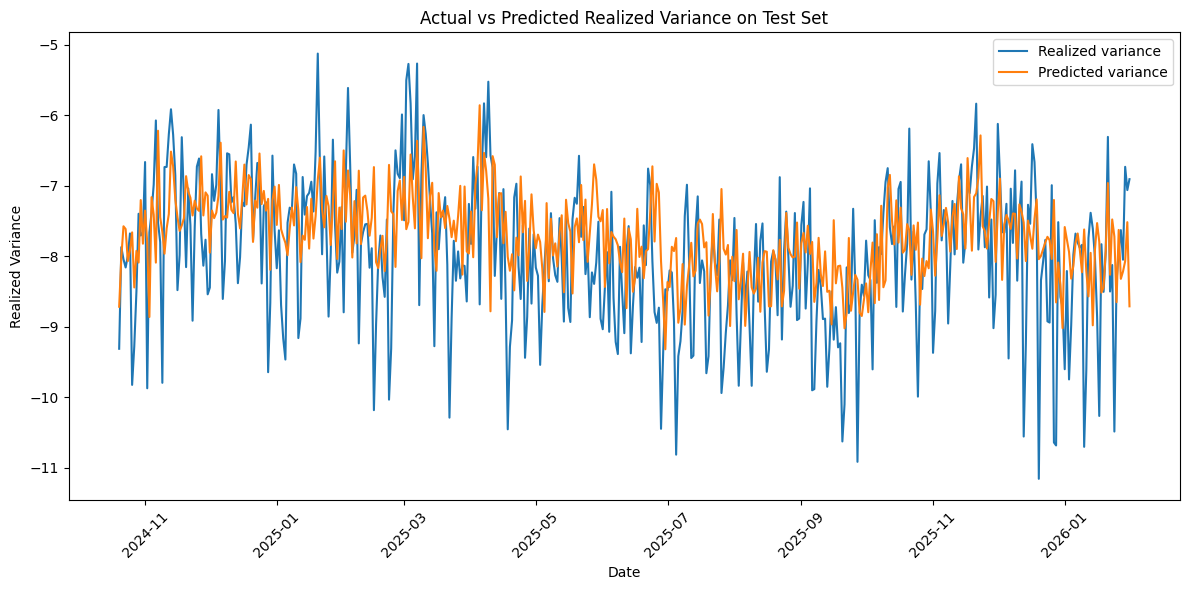

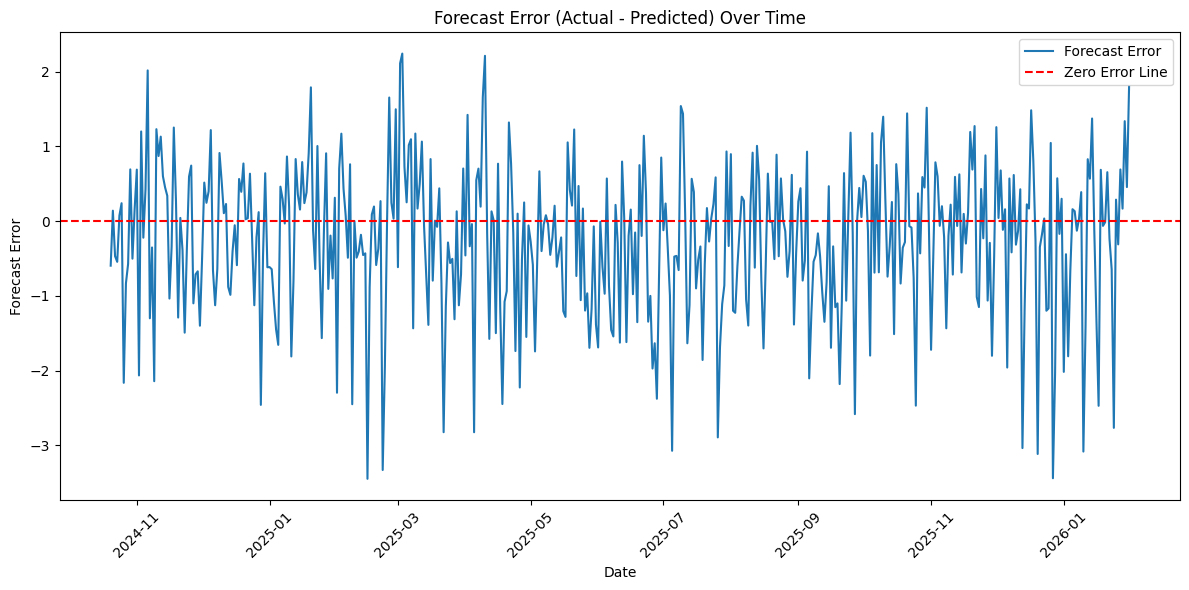

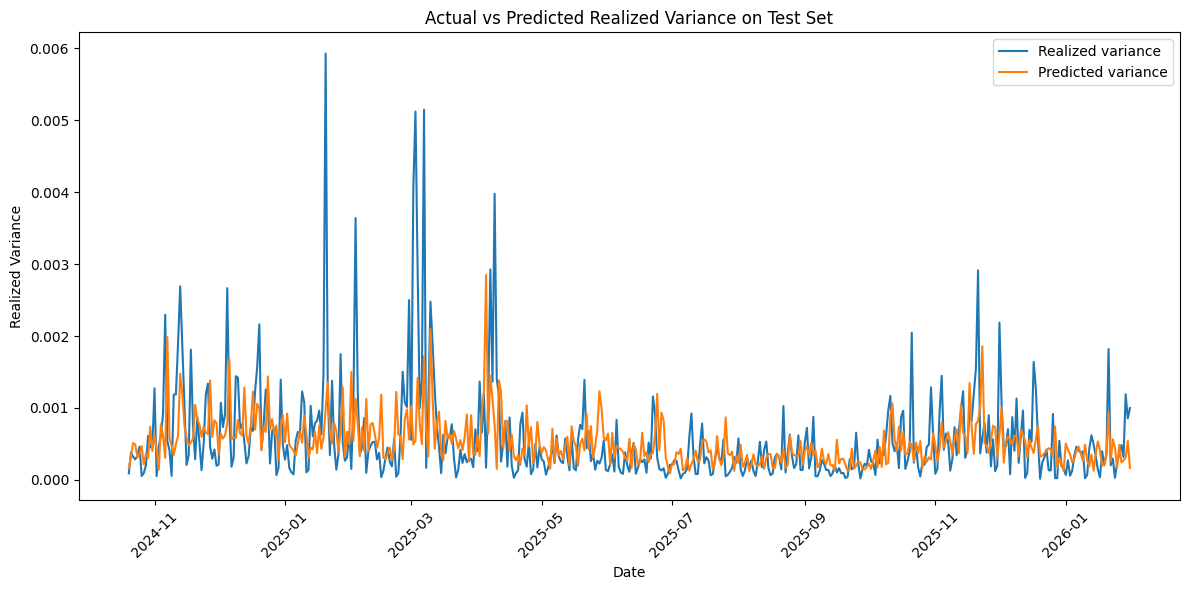

In [19]:
# plot actual vs predicted variance on test set
import matplotlib.pyplot as plt
test_rf['date'] = pd.to_datetime(test_rf['date'])
plt.figure(figsize=(12,6))
plt.plot(test_rf["date"], test_rf["actual_log_var"], label="Realized variance")
plt.plot(test_rf["date"], test_rf["log_var_svr"], label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_rf['date'] = pd.to_datetime(test_rf['date'])
test_rf['error'] = test_rf["actual_log_var"] - test_rf["log_var_svr"]
plt.figure(figsize=(12,6))
plt.plot(test_rf["date"], test_rf["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


test_rf['date'] = pd.to_datetime(test_rf['date'])
plt.figure(figsize=(12,6))
plt.plot(test_rf["date"], np.exp(test_rf["actual_log_var"]), label="Realized variance")
plt.plot(test_rf["date"], np.exp(test_rf["log_var_svr"]), label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
# export test_rf to csv 
#test_rf.to_csv("results/rf-svr2_results.csv", index=False)

# Feature Importance and SHAP values

**RF built-in feature importances**

In [23]:
feature_importance = pd.Series(final_rf_model.feature_importances_,
                               index=rf_features
                              ).sort_values(ascending=False)

feature_importance.head(10)

log_volume                                    0.405114
log_return                                    0.102398
gtrend_pct_change                             0.074885
blockchain_diff_log_transaction_volume_usd    0.026502
gold_volume_chg                               0.024769
spx_close_ret                                 0.024061
brent_volume_chg                              0.021718
nasdaq_close_ret                              0.021221
blockchain_diff_log_n_unique_addresses        0.020413
gold_close_ret                                0.019307
dtype: float64

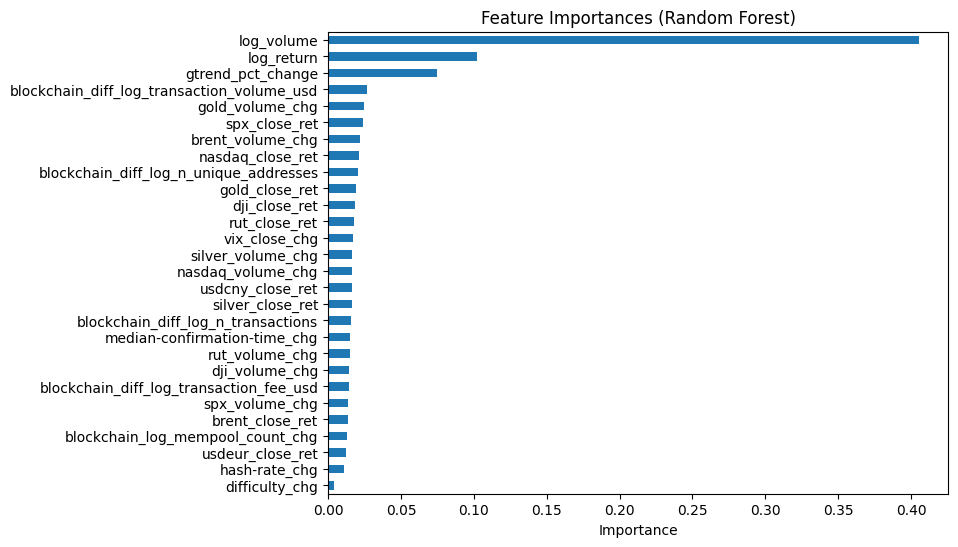

In [25]:
feature_importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.xlabel("Importance")
plt.title("Feature Importances (Random Forest)");
#plt.savefig("RF2_featureimpt.png", bbox_inches="tight")

**Permutation Importance using library (Macro F1 Score)**

In [26]:
X_test_rf = df.iloc[test_start_idx-1:test_end_idx-1][rf_features].copy()
y_test_rf = df.iloc[test_start_idx-1:test_end_idx-1]["regime_id"].copy()

perm_importance = permutation_importance(
    final_rf_model,
    X_test_rf,
    y_test_rf,
    n_repeats=5, # default value is 5 so i kept it 5
    random_state=SEED,
    scoring="f1_macro"
)

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without featur

In [27]:
rf_perm_feature_importance = pd.DataFrame({
    "feature":rf_features,
    "mean_importance":perm_importance.importances_mean,
}).sort_values(by="mean_importance", ascending=False)

print(rf_perm_feature_importance)

                                       feature  mean_importance
6                                   log_volume     1.152262e-01
0                                   log_return     1.187772e-02
1                            gtrend_pct_change     5.981310e-03
5   blockchain_diff_log_transaction_volume_usd     5.811946e-03
21                              rut_volume_chg     3.316360e-03
11                               spx_close_ret     1.936132e-03
17                           silver_volume_chg     1.525296e-03
22                           nasdaq_volume_chg     1.197427e-03
24                               hash-rate_chg     4.502701e-04
26                median-confirmation-time_chg     4.470513e-04
25                              difficulty_chg     4.462467e-04
3      blockchain_diff_log_transaction_fee_usd     8.046765e-07
2           blockchain_diff_log_n_transactions    -6.231831e-05
15                            usdeur_close_ret    -4.106208e-04
27            blockchain_log_mempool_cou

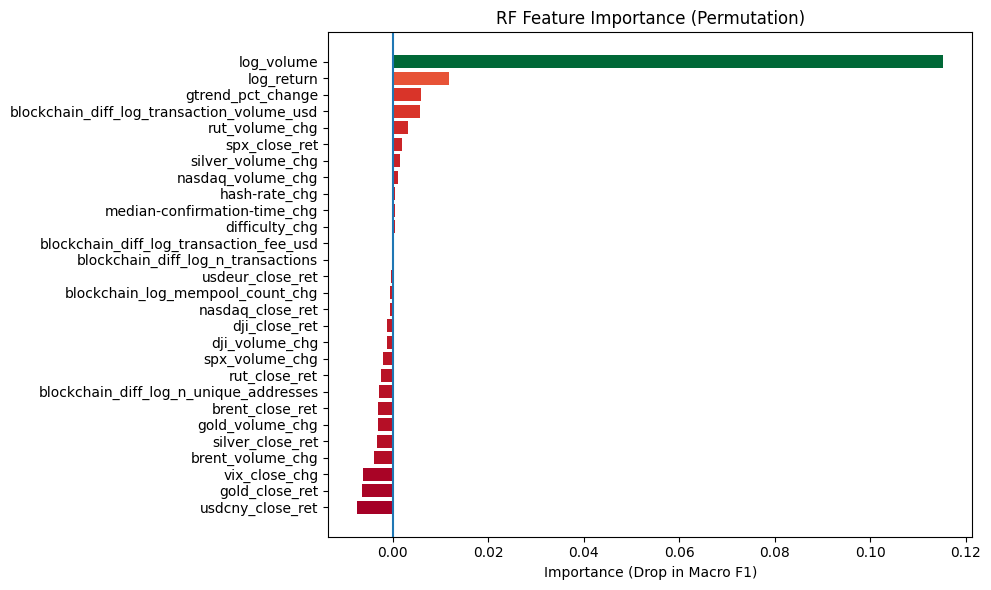

In [29]:
top_n = 28
plot_df = rf_perm_feature_importance.head(top_n).iloc[::-1]

values = plot_df["mean_importance"].values

# normalize values to [-1, 1]
norm = plt.Normalize(vmin=values.min(), vmax=values.max())


cmap = plt.cm.RdYlGn

colors = cmap(norm(values))

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["mean_importance"], color=colors)

plt.axvline(0)

plt.title("RF Feature Importance (Permutation)")
plt.xlabel("Importance (Drop in Macro F1)")

plt.tight_layout()
#plt.savefig("RF2_permfeatimpt_library.png", bbox_inches="tight")
plt.show()

**Permutation Importance using same function defined in LSTM**

In [30]:
from sklearn.metrics import f1_score

def macro_f1_metric(y_true, y_pred):
    y_pred = np.array(y_pred)

    # multiclass / softmax case
    if y_pred.ndim == 2 and y_pred.shape[1] > 1:
        y_pred_class = np.argmax(y_pred, axis=1)
    # binary sigmoid case
    else:
        y_pred_class = (y_pred.ravel() >= 0.5).astype(int)

    return f1_score(y_true, y_pred_class, average="macro")

def permutation_importance_lstm(model, X, y, metric_fn):
    baseline_pred = model.predict(X)
    baseline_score = metric_fn(y, baseline_pred)

    importances = []

    for j in range(X_test_rf.shape[1]):  # loop over features
        X_permuted = X.copy()

        # permute feature j across samples
        rng = np.random.RandomState(SEED)
        perm_idx = rng.permutation(X.shape[0])
        col = X.columns[j]
        X_permuted[col] = X_permuted[col].iloc[perm_idx].values

        perm_pred = model.predict(X_permuted)
        perm_score = metric_fn(y, perm_pred)

        importance = baseline_score - perm_score
        importances.append(importance)

    return np.array(importances)

importances = permutation_importance_lstm(
    model=final_rf_model,
    X=X_test_rf,
    y=y_test_rf,
    metric_fn=macro_f1_metric
)

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without featur

In [31]:
importance_df = pd.DataFrame({
    "feature": rf_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(importance_df)

                                       feature  importance
6                                   log_volume    0.103066
0                                   log_return    0.014905
11                               spx_close_ret    0.008569
10                               dji_close_ret    0.004467
17                           silver_volume_chg    0.002616
5   blockchain_diff_log_transaction_volume_usd    0.002231
12                               rut_close_ret    0.000180
25                              difficulty_chg    0.000000
24                               hash-rate_chg    0.000000
27            blockchain_log_mempool_count_chg    0.000000
2           blockchain_diff_log_n_transactions    0.000000
7                               gold_close_ret   -0.001871
23                               vix_close_chg   -0.002054
22                           nasdaq_volume_chg   -0.002054
21                              rut_volume_chg   -0.002054
9                              brent_close_ret   -0.0022

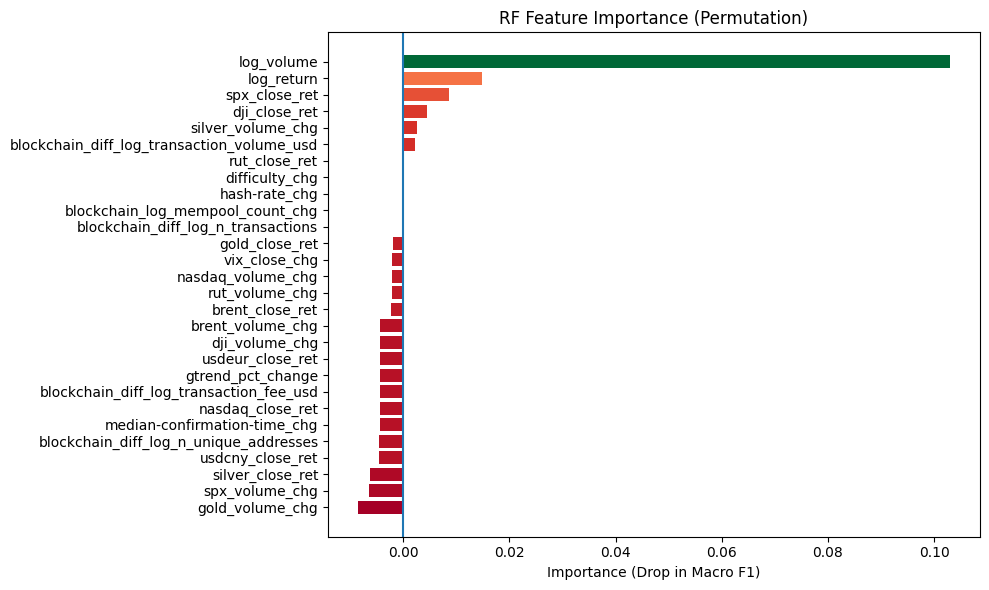

In [33]:
top_n = 28
plot_df = importance_df.head(top_n).iloc[::-1]

values = plot_df["importance"].values

# normalize values to [-1, 1]
norm = plt.Normalize(vmin=values.min(), vmax=values.max())

cmap = plt.cm.RdYlGn
colors = cmap(norm(values))

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"], color=colors)

plt.axvline(0)

plt.title("RF Feature Importance (Permutation)")
plt.xlabel("Importance (Drop in Macro F1)")
plt.tight_layout()
#plt.savefig("RF2_permfeatimpt_customfunction.png", bbox_inches="tight")
plt.show()

**SHAP Values**

In [34]:
# Since RF model is only trained once on training data and not re-trained each window, can just compute SHAP values on test set in one go
# But, first check if X_test_rf aligns with our rolling window X set

X_test_rf = df.iloc[test_start_idx-1:test_end_idx-1][rf_features].copy()
probs_check = final_rf_model.predict_proba(X_test_rf)
probs_check

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


array([[0.79428346, 0.20571654],
       [0.75538981, 0.24461019],
       [0.47329402, 0.52670598],
       [0.53972551, 0.46027449],
       [0.4290547 , 0.5709453 ],
       [0.41491045, 0.58508955],
       [0.40345585, 0.59654415],
       [0.79020878, 0.20979122],
       [0.76416396, 0.23583604],
       [0.27944923, 0.72055077],
       [0.22720662, 0.77279338],
       [0.3832143 , 0.6167857 ],
       [0.30863255, 0.69136745],
       [0.38561931, 0.61438069],
       [0.73656804, 0.26343196],
       [0.69471138, 0.30528862],
       [0.46924936, 0.53075064],
       [0.38215294, 0.61784706],
       [0.20051605, 0.79948395],
       [0.30694718, 0.69305282],
       [0.28607524, 0.71392476],
       [0.76506316, 0.23493684],
       [0.29211275, 0.70788725],
       [0.19990162, 0.80009838],
       [0.28829608, 0.71170392],
       [0.29580278, 0.70419722],
       [0.25047332, 0.74952668],
       [0.21516391, 0.78483609],
       [0.74818834, 0.25181166],
       [0.74382351, 0.25617649],
       [0.

In [35]:
# Compare with test_rf's predicted probabilities, which aligns
test_rf

,date,forecast_origin_date,actual_log_var,pred_regime,pred_prob_0,pred_prob_1,log_var_svr,error
0,2024-10-20,2024-10-19,-9.314845,0.0,0.794283,0.205717,-8.718822,-0.596023
1,2024-10-21,2024-10-20,-7.873473,0.0,0.755390,0.244610,-8.013335,0.139862
2,2024-10-22,2024-10-21,-8.046507,1.0,0.473294,0.526706,-7.577555,-0.468953
3,2024-10-23,2024-10-22,-8.161787,0.0,0.539726,0.460274,-7.616970,-0.544818
4,2024-10-24,2024-10-23,-7.997675,1.0,0.429055,0.570945,-8.071370,0.073695
...,...,...,...,...,...,...,...,...
464,2026-01-27,2026-01-26,-7.631798,0.0,0.543810,0.456190,-8.322983,0.691185
465,2026-01-28,2026-01-27,-8.051862,0.0,0.610677,0.389323,-8.218895,0.167033
466,2026-01-29,2026-01-28,-6.734192,0.0,0.593567,0.406433,-8.071716,1.337523
467,2026-01-30,2026-01-29,-7.064056,1.0,0.259453,0.740547,-7.519493,0.455437


In [36]:
explainer = shap.TreeExplainer(final_rf_model)
shap_values = explainer.shap_values(X_test_rf)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25652\3449892529.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test_rf, show = False)


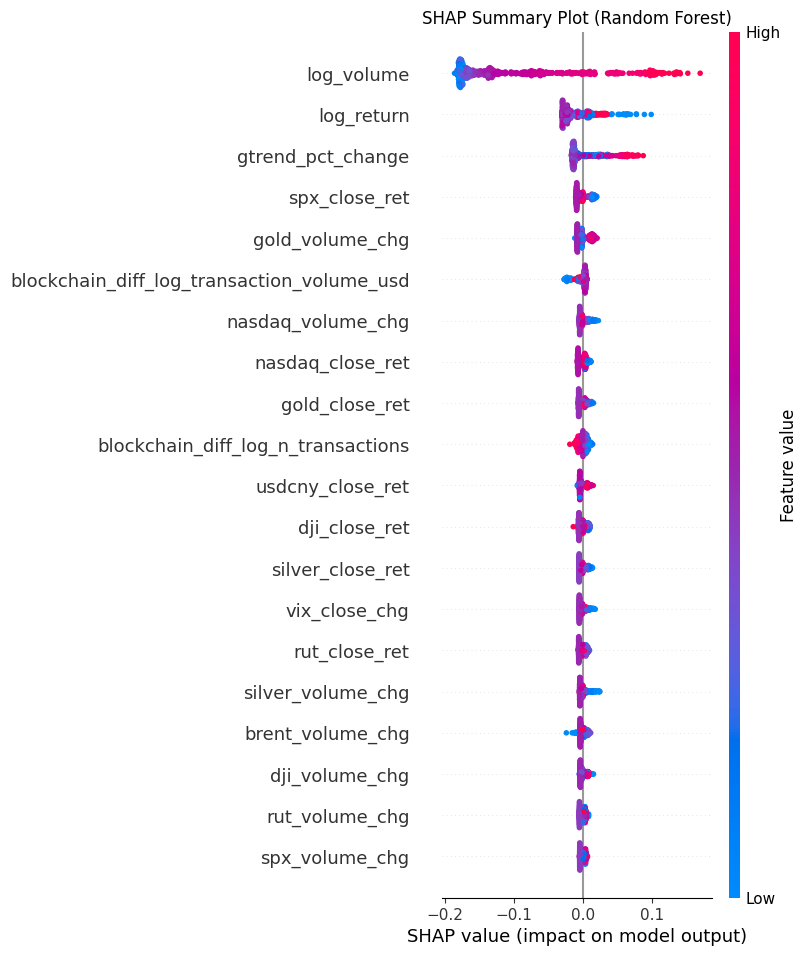

In [38]:
shap.summary_plot(shap_values[:, :, 1], X_test_rf, show = False)
plt.title("SHAP Summary Plot (Random Forest)")
#plt.savefig("RF2_shapsummary.png", bbox_inches="tight")
plt.show()

# Classification report

In [39]:
# Convert to datetime and merge to obtain actual and predicted labels
df['date'] = pd.to_datetime(df['date'])
test_rf['date'] = pd.to_datetime(test_rf['date'])

result_df = test_rf.merge(
    df[["date", "regime_id"]],
    on="date",
    how="left"
)

result_df = result_df.rename(columns={"regime_id": "actual_regime"})

result_df.head(20)

,date,forecast_origin_date,actual_log_var,pred_regime,pred_prob_0,pred_prob_1,log_var_svr,error,actual_regime
0,2024-10-20,2024-10-19,-9.314845,0.0,0.794283,0.205717,-8.718822,-0.596023,0.0
1,2024-10-21,2024-10-20,-7.873473,0.0,0.755390,0.244610,-8.013335,0.139862,0.0
2,2024-10-22,2024-10-21,-8.046507,1.0,0.473294,0.526706,-7.577555,-0.468953,0.0
3,2024-10-23,2024-10-22,-8.161787,0.0,0.539726,0.460274,-7.616970,-0.544818,0.0
4,2024-10-24,2024-10-23,-7.997675,1.0,0.429055,0.570945,-8.071370,0.073695,0.0
5,2024-10-25,2024-10-24,-7.679053,1.0,0.414910,0.585090,-7.918612,0.239559,1.0
6,2024-10-26,2024-10-25,-9.827359,1.0,0.403456,0.596544,-7.664053,-2.163306,0.0
7,2024-10-27,2024-10-26,-9.277379,0.0,0.790209,0.209791,-8.445253,-0.832126,0.0
8,2024-10-28,2024-10-27,-8.498660,0.0,0.764164,0.235836,-7.926032,-0.572628,0.0
9,2024-10-29,2024-10-28,-7.399876,1.0,0.279449,0.720551,-8.091865,0.691989,1.0


In [40]:
# Check for any NA's
result_df[["pred_regime", "actual_regime"]].isna().any()

pred_regime      False
actual_regime    False
dtype: bool

In [41]:
# Classification report
print(classification_report(result_df["actual_regime"], result_df["pred_regime"]))

              precision    recall  f1-score   support

         0.0       0.55      0.73      0.63       214
         1.0       0.69      0.49      0.58       255

    accuracy                           0.60       469
   macro avg       0.62      0.61      0.60       469
weighted avg       0.62      0.60      0.60       469

